In [3]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import FallOff
from diffPLOG2TROE.rate_constants import Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter
from diffPLOG2TROE.optimization import LossType

import matplotlib.pyplot as plt

In [34]:
starting_plog = {
    "name": "HNO+H=H2NO",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01,  5.670E+23, -4.590, 5690.0],
            [0.10,  5.690E+25, -4.800, 4233.0],
            [1.00,  2.680E+27, -4.940, 4849.0],
            [10.0,  2.550E+27, -4.630, 5539.0],
            [100.0, 4.840E+25, -3.870, 5867.0],
        ]
    },
}
starting_plog = {
    "name": "HNO2=HONO",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01, 3.260000e+34, -7.97, 45490.0],
            [0.1,  2.770000e+33, -7.58, 45250.0],
            [0.316, 1.930000e+32, -7.18, 44940.0],
            [1.0,  1.560000e+30, -6.47, 44360.0],
            [3.16, 2.170000e+27, -5.49, 43670.0],
            [10.0, 4.680000e+24, -4.52, 43320.0],
            [31.6, 1.140000e+23, -3.81, 43640.0],
            [100.0, 2.030000e+22, -3.35, 44430.0]
        ]
    },
}

starting_plog = {
    "name": "OH+NO=HONO",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01, 5.020000e+21, -4.24, 898.9],
            [0.1,  5.310000e+22, -4.24, 1184.0],
            [0.316, 1.380000e+23, -4.22, 1376.0],
            [1.0,  3.090000e+23, -4.17, 1621.0],
            [3.16,  5.450000e+23, -4.09, 1911.0],
            [10.0,  6.350000e+23, -3.97, 2222.0],
            [31.6,  3.680000e+23, -3.75, 2501.0],
            [100.0, 7.290000e+22, -3.41, 2660.0]
        ]
    },
}

param_config = {
    "A_low":  {"optimize": True,  "value": 5.670E+24},
    "n_low":  {"optimize": True,  "value": -3.58622},
    "E_low":  {"optimize": True,  "value": 1.25522e+03},
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(400, 2200),
    P_range=(0.01, 100),
    n_T=100,
    n_P=100,
    # param_config=param_config,
    loss_name="log",
    log_name="nlopt-refit-logloss-lbfgs.log"
)

nlopt_options = {
    "algorithm": "ISRES",
    "max_eval": 200000,
    "ftol_rel": 1e-15,
    "xtol_rel": 1e-15,
    "steps_file": 1000
}

initial_troe = refitter.fit(nlopt_options=nlopt_options)
print(FallOff(initial_troe))

Plog 2 TROE refitter
 Temperature range [K]: (400, 2200)
 Pressure range [atm]: (0.01, 100)
 Loss function: log

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: optimizing from default initial value
  n_high: optimizing from default initial value
  E_high: optimizing from default initial value
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value
Starting optimization
First guess estimate of the parameters:
  High pressure limit (A, n, Ea): 7.290e+22, -3.410, 2.660e+03
  Low pressure limit (A, n, Ea): 4.119e+25, -3.240, 8.989e+02
  Troe parameters (A, T3, T1, T2): 0.500, 9.100e+02, 2.600e+02, 1.950e+03

  Step 0: loss = 4.904439e-01
  Step 1000: loss = 1.112983e+01
  Step 2000: loss = 6.004566e+00
  Step 3000: loss = 2.062631e+01
  Step 400

OH+NO=HONO		9.25952e+19 -2.01656 3.64475e+03
 LOW / 		1.71671e+25 -3.09474 5.71623e+02 /
 TROE / 2.21482e-01 1.72787e+02 2.09862e+29 6.81695e+29 /


Minimum error: 0.8159714782963862
Maximum error: 1.1307951179115854
Average error: 0.02893813282226374


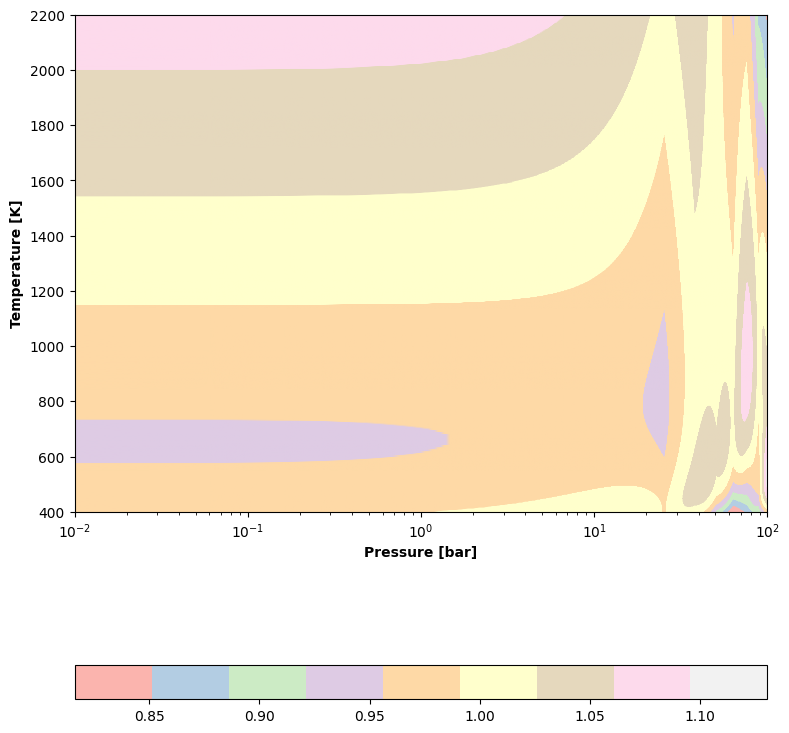

In [35]:
T_range = jnp.linspace(400, 2200, 1000)
P_range = jnp.logspace(jnp.log10(0.01), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_falloff_map.T / k_plog_map.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel1"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()

In [ ]:
T_range = jnp.linspace(600, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.01), jnp.log10(100), 4)
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)

# Calculate ratios at each pressure
ratios = k_falloff_map / k_plog_map

# Print min and max ratios for each pressure
print("\nRatios (Falloff/PLOG) at each pressure:")
print("-" * 40)
for i in range(len(P_range)):
    min_ratio = float(jnp.min(ratios[i]))
    max_ratio = float(jnp.max(ratios[i]))
    print(f"P = {float(P_range[i]):.2f} atm:")
    print(f"  Min ratio: {min_ratio:.2e}")
    print(f"  Max ratio: {max_ratio:.2e}")
    print(f"  Temperature at min ratio: {float(T_range[jnp.argmin(ratios[i])]):.1f} K")
    print(f"  Temperature at max ratio: {float(T_range[jnp.argmax(ratios[i])]):.1f} K")
    print()

# Create plot
num_pressures = len(P_range)
colors = plt.cm.viridis(jnp.linspace(0, 1, num_pressures))

plt.figure(figsize=(10, 12))
legend1_lines = []

for i in range(num_pressures):
    color = colors[i]
    line1 = plt.plot(T_range, k_falloff_map[i],
                     label=f'P={float(P_range[i]):.2f} atm',
                     linestyle='-', color=color)[0]
    plt.plot(T_range, k_plog_map[i], linestyle='--', color=color)
    legend1_lines.append(line1)

line_falloff = plt.plot([], [], color='black', linestyle='-', label='Falloff')[0]
line_plog = plt.plot([], [], color='black', linestyle='--', label='PLOG')[0]

plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Rate Constant')
plt.title('Comparison of Falloff and PLOG Rates')

plt.gca().set_box_aspect(1)
plt.subplots_adjust(right=0.8)

legend1 = plt.legend(handles=legend1_lines, bbox_to_anchor=(0.72, 1), loc='upper left')
plt.legend(handles=[line_falloff, line_plog], bbox_to_anchor=(0.02, 0.1), loc='upper left')
plt.gca().add_artist(legend1)

plt.grid(True)
plt.show()